## <font color="cyan">Dataset column description</font>

| Field | Description |
|---|---|
| FileName | of CTG examination |
| Date | of the examination |
| b | start instant |
| e | end instant |
| LBE | baseline value (medical expert) |
| LB | baseline value (SisPorto) |
| AC | accelerations (SisPorto) |
| FM | foetal movement (SisPorto) |
| UC | uterine contractions (SisPorto) |
| ASTV | percentage of time with abnormal short term variability (SisPorto) |
| mSTV | mean value of short term variability (SisPorto) |
| ALTV | percentage of time with abnormal long term variability (SisPorto) |
| mLTV | mean value of long term variability (SisPorto) |
| DL | light decelerations |
| DS | severe decelerations |
| DP | prolongued decelerations |
| DR | repetitive decelerations |
| Width | histogram width |
| Min | low freq. of the histogram |
| Max | high freq. of the histogram |
| Nmax | number of histogram peaks |
| Nzeros | number of histogram zeros |
| Mode | histogram mode |
| Mean | histogram mean |
| Median | histogram median |
| Variance | histogram variance |
| Tendency | histogram tendency: -1=left assymetric; 0=symmetric; 1=right assymetric |
| A | calm sleep |
| B | REM sleep |
| C | calm vigilance |
| D | active vigilance |
| SH | shift pattern (A or Susp with shifts) |
| AD | accelerative/decelerative pattern (stress situation) |
| DE | decelerative pattern (vagal stimulation) |
| LD | largely decelerative pattern |
| FS | flat-sinusoidal pattern (pathological state) |
| SUSP | suspect pattern |
| CLASS | Class code (1 to 10) for classes A to SUSP |
| NSP | Normal=1; Suspect=2; Pathologic=3 |


In [3]:

# Load libraries

# Librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM


In [4]:
import seaborn as sb
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM


In [5]:
# Load Dataset
data = pd.read_csv('../datasets/CTG.csv')
data.head(5)



,FileName,Date,SegFile,b,e,LBE,LB,AC,FM,UC,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,Variab10.txt,12/1/1996,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,Fmcs_1.txt,5/3/1996,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,Fmcs_1.txt,5/3/1996,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,Fmcs_1.txt,5/3/1996,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,Fmcs_1.txt,5/3/1996,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [6]:
#Tamaño del dataset
data.shape


(2129, 40)

In [7]:
#Información de las variables
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2129 entries, 0 to 2128
Data columns (total 40 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   FileName  2126 non-null   object 
 1   Date      2126 non-null   object 
 2   SegFile   2126 non-null   object 
 3   b         2126 non-null   float64
 4   e         2126 non-null   float64
 5   LBE       2126 non-null   float64
 6   LB        2126 non-null   float64
 7   AC        2126 non-null   float64
 8   FM        2127 non-null   float64
 9   UC        2127 non-null   float64
 10  ASTV      2127 non-null   float64
 11  MSTV      2127 non-null   float64
 12  ALTV      2127 non-null   float64
 13  MLTV      2127 non-null   float64
 14  DL        2128 non-null   float64
 15  DS        2128 non-null   float64
 16  DP        2128 non-null   float64
 17  DR        2128 non-null   float64
 18  Width     2126 non-null   float64
 19  Min       2126 non-null   float64
 20  Max       2126 non-null   floa

## <font color="cyan">Validaciones</font>

Validando la existencia de valores nulos:

In [8]:
count_null = data.isnull().sum()
count_null

FileName    3
Date        3
SegFile     3
b           3
e           3
LBE         3
LB          3
AC          3
FM          2
UC          2
ASTV        2
MSTV        2
ALTV        2
MLTV        2
DL          1
DS          1
DP          1
DR          1
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
A           3
B           3
C           3
D           3
E           3
AD          3
DE          3
LD          3
FS          3
SUSP        3
CLASS       3
NSP         3
dtype: int64

In [9]:
### Validando NaN values
count_na = data.isna().sum()
count_na


FileName    3
Date        3
SegFile     3
b           3
e           3
LBE         3
LB          3
AC          3
FM          2
UC          2
ASTV        2
MSTV        2
ALTV        2
MLTV        2
DL          1
DS          1
DP          1
DR          1
Width       3
Min         3
Max         3
Nmax        3
Nzeros      3
Mode        3
Mean        3
Median      3
Variance    3
Tendency    3
A           3
B           3
C           3
D           3
E           3
AD          3
DE          3
LD          3
FS          3
SUSP        3
CLASS       3
NSP         3
dtype: int64

### <font color="cyan">Remover columnas que no agregan valor al análisis</font>

Se remueven las siguientes columnas debido que no aportan información para este análisis:
* `Filename`
* `SegFile`
* `Date`

También se remueven las columnas relacionadas a la tendencia del histograma:

* `Width`
* `Min`
* `Max`
* `Nmax`
* `Nzeros`
* `Mode`
* `Mean`
* `Median`
* `Variance`

También se remueven las columnas relacionadas con los instantes de inicio y finalización debido a que no indican un parámetro temporal que pueda ser comparado (si son segundos, milisegundos, inicio con respecto a algún marcador temporal)

* `b`
* `e`


In [10]:
# Remove FileName column
data = data.drop(columns=['FileName', 'SegFile', 'Date', 'b', 'e', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency'])
# data = data.drop(columns=['FileName', 'SegFile', 'Date'])
data.head()

,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,43.0,2.4,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,132.0,132.0,4.0,0.0,4.0,17.0,2.1,0.0,10.4,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,133.0,133.0,2.0,0.0,5.0,16.0,2.1,0.0,13.4,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,134.0,134.0,2.0,0.0,6.0,16.0,2.4,0.0,23.0,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,132.0,132.0,4.0,0.0,5.0,16.0,2.4,0.0,19.9,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


In [11]:
count_na = data.isna().sum()
count_na

LBE      3
LB       3
AC       3
FM       2
UC       2
ASTV     2
MSTV     2
ALTV     2
MLTV     2
DL       1
DS       1
DP       1
DR       1
A        3
B        3
C        3
D        3
E        3
AD       3
DE       3
LD       3
FS       3
SUSP     3
CLASS    3
NSP      3
dtype: int64

### <font color="cyan">Método de validación utilizado</font>

Debido a que la totalidad de valores nulos se encuentran en las últimas tres filas, se procede a elimiar dichas filas dado que la cantidad no es significativo para la todalidad de datos

In [12]:
shape = data.shape

data = data.iloc[:-3]

shape_after = data.shape

data.tail(10)

,LBE,LB,AC,FM,UC,ASTV,MSTV,ALTV,MLTV,DL,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
2116,140.0,140.0,1.0,0.0,1.0,80.0,0.2,36.0,2.2,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0
2117,140.0,140.0,0.0,0.0,6.0,79.0,0.3,20.0,8.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2118,140.0,140.0,0.0,0.0,7.0,79.0,0.5,26.0,7.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2119,140.0,140.0,0.0,0.0,6.0,79.0,0.6,27.0,6.4,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2120,140.0,140.0,0.0,0.0,4.0,77.0,0.7,17.0,6.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2121,140.0,140.0,0.0,0.0,6.0,79.0,0.2,25.0,7.2,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2122,140.0,140.0,1.0,0.0,9.0,78.0,0.4,22.0,7.1,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2123,140.0,140.0,1.0,0.0,7.0,79.0,0.4,20.0,6.1,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2124,140.0,140.0,1.0,0.0,9.0,78.0,0.4,27.0,7.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0
2125,142.0,142.0,1.0,1.0,5.0,74.0,0.4,36.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


Se remueve la columna `DR` debido a que no presenta valores que puedan ser analizados

In [13]:
data['DR'].value_counts()

DR
0.0    2126
Name: count, dtype: int64

In [14]:
data.drop(columns=['DR'], inplace=True)

In [15]:
print(f"La cantidad de filas antes de eliminar las filas con NaN/nulos es: {shape}")
print(f"La cantidad de filas después de eliminar las filas con NaN/nulos es: {shape_after}")

La cantidad de filas antes de eliminar las filas con NaN/nulos es: (2129, 25)
La cantidad de filas después de eliminar las filas con NaN/nulos es: (2126, 25)


## <font color="cyan">Análisis Exploratorio (EDA)</font>

In [16]:
# Variables numéricas discretas
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   LBE     2126 non-null   float64
 1   LB      2126 non-null   float64
 2   AC      2126 non-null   float64
 3   FM      2126 non-null   float64
 4   UC      2126 non-null   float64
 5   ASTV    2126 non-null   float64
 6   MSTV    2126 non-null   float64
 7   ALTV    2126 non-null   float64
 8   MLTV    2126 non-null   float64
 9   DL      2126 non-null   float64
 10  DS      2126 non-null   float64
 11  DP      2126 non-null   float64
 12  A       2126 non-null   float64
 13  B       2126 non-null   float64
 14  C       2126 non-null   float64
 15  D       2126 non-null   float64
 16  E       2126 non-null   float64
 17  AD      2126 non-null   float64
 18  DE      2126 non-null   float64
 19  LD      2126 non-null   float64
 20  FS      2126 non-null   float64
 21  SUSP    2126 non-null   float64
 22  

In [17]:
# Variables numéricas continuas
float_vars = list(data.select_dtypes(include='float'))

# Variables categóricas
categorical_variables = ['CLASS', 'NSP']
print(f'Variables categóricas\n{categorical_variables}')


# Variables numéricas continuas
continuous_vars = list(set(float_vars) - set(categorical_variables))
print(f'Variables numéricas continuas\n{continuous_vars}')


Variables categóricas
['CLASS', 'NSP']
Variables numéricas continuas
['UC', 'LBE', 'DE', 'FM', 'E', 'FS', 'AD', 'LB', 'B', 'D', 'DL', 'A', 'AC', 'MSTV', 'C', 'ALTV', 'DS', 'ASTV', 'MLTV', 'DP', 'SUSP', 'LD']


### <font color="cyan">Resumen estadístico</font>

In [18]:

data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
LBE,2126.0,133.303857,9.840844,106.0,126.0,133.0,140.0,160.0
LB,2126.0,133.303857,9.840844,106.0,126.0,133.0,140.0,160.0
AC,2126.0,2.722484,3.560850,0.0,0.0,1.0,4.0,26.0
FM,2126.0,7.241298,37.125309,0.0,0.0,0.0,2.0,564.0
UC,2126.0,3.659925,2.847094,0.0,1.0,3.0,5.0,23.0
ASTV,2126.0,46.990122,17.192814,12.0,32.0,49.0,61.0,87.0
MSTV,2126.0,1.332785,0.883241,0.2,0.7,1.2,1.7,7.0
ALTV,2126.0,9.846660,18.396880,0.0,0.0,0.0,11.0,91.0
MLTV,2126.0,8.187629,5.628247,0.0,4.6,7.4,10.8,50.7
DL,2126.0,1.570085,2.499229,0.0,0.0,0.0,3.0,16.0


In [19]:
# Resumen estadístico ampliado con mean, median y mode
desc = data.describe(include='all').transpose()

# media y mediana (solo para numéricas; el resto queda NaN)
desc['mean'] = data.mean(numeric_only=True)
desc['median'] = data.median(numeric_only=True)

# moda: tomar el primer valor de la(s) moda(s) por columna (funciona para numéricas y categóricas)
modes = data.mode(dropna=True)
if not modes.empty:
    first_mode = modes.iloc[0]
else:
    first_mode = pd.Series(index=data.columns, dtype=object)
desc['mode'] = first_mode

# reordenar columnas para presentación (opcional)
cols_order = ['count','mean','median','mode','std','min','25%','50%','75%','max','unique','top','freq']
desc = desc.reindex(columns=[c for c in cols_order if c in desc.columns])

desc


,count,mean,median,mode,std,min,25%,50%,75%,max
LBE,2126.0,133.303857,133.0,133.0,9.840844,106.0,126.0,133.0,140.0,160.0
LB,2126.0,133.303857,133.0,133.0,9.840844,106.0,126.0,133.0,140.0,160.0
AC,2126.0,2.722484,1.0,0.0,3.560850,0.0,0.0,1.0,4.0,26.0
FM,2126.0,7.241298,0.0,0.0,37.125309,0.0,0.0,0.0,2.0,564.0
UC,2126.0,3.659925,3.0,0.0,2.847094,0.0,1.0,3.0,5.0,23.0
ASTV,2126.0,46.990122,49.0,60.0,17.192814,12.0,32.0,49.0,61.0,87.0
MSTV,2126.0,1.332785,1.2,0.8,0.883241,0.2,0.7,1.2,1.7,7.0
ALTV,2126.0,9.846660,0.0,0.0,18.396880,0.0,0.0,0.0,11.0,91.0
MLTV,2126.0,8.187629,7.4,0.0,5.628247,0.0,4.6,7.4,10.8,50.7
DL,2126.0,1.570085,0.0,0.0,2.499229,0.0,0.0,0.0,3.0,16.0


### <font color="cyan">Frecuencia Variables Categóricas</font>

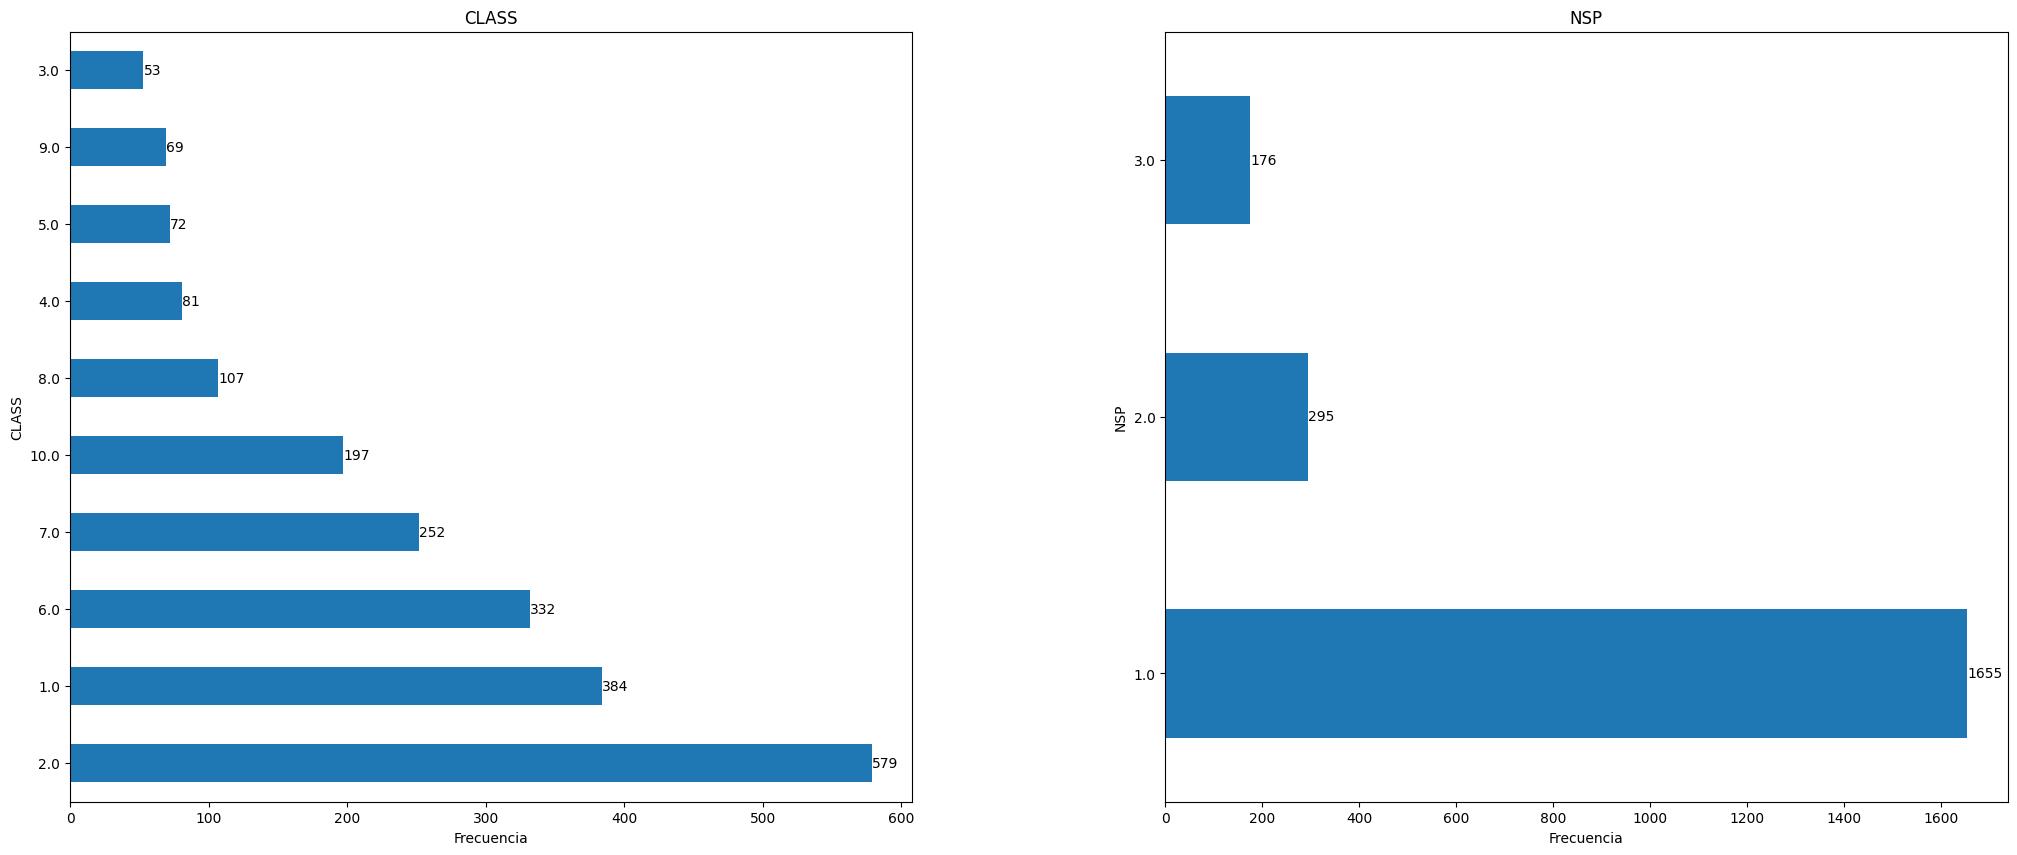

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(25, 10))

plt.subplots_adjust(
    wspace = 0.3,
    hspace = 0.3
)

for col, ax in zip(categorical_variables, axes.ravel()):
  data[col].value_counts().plot.barh(ax=ax)
  ax.set_xlabel('Frecuencia')
  ax.set_title(col)
  ax.bar_label(ax.containers[0])

plt.show()


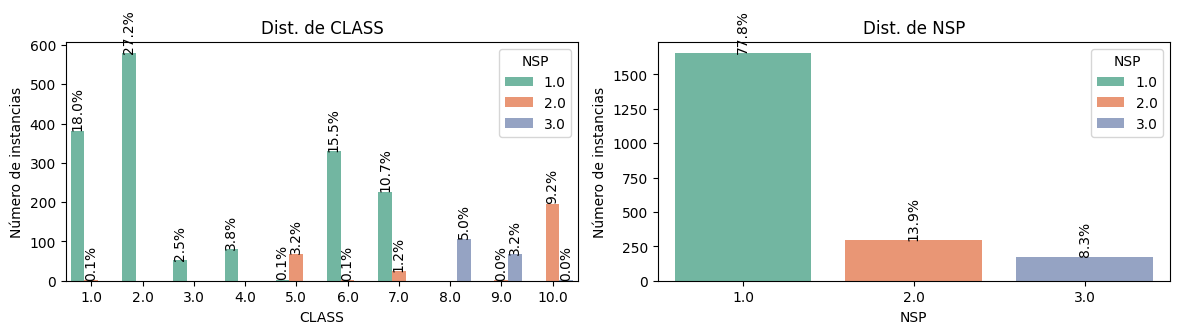

In [21]:
cols = 2
rows = (len(categorical_variables) // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(cols * 7, rows * 3))
axes = axes.flatten()  # Aplana la matriz de ejes para facilitar el acceso

for idx, column in enumerate(categorical_variables):
    ax = sb.countplot(x=column, hue='NSP', data=data[categorical_variables], palette="Set2", ax=axes[idx])
    axes[idx].set_title(f"Dist. de {column}")
    axes[idx].set_xlabel(column)
    axes[idx].set_ylabel('Número de instancias')

    # Agregar porcentajes sobre cada barra con rotación
    total = len(data[categorical_variables])
    for p in ax.patches:
        height = p.get_height()
        if height > 0:  # Solo añadir el porcentaje si la altura es mayor que cero
            # Calcular el porcentaje
            percentage = f'{100 * height / total:.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = p.get_y() + height
            # Añadir el porcentaje como anotación con rotación
            ax.annotate(percentage, (x, y), ha='center', va='bottom', rotation=90)

# Eliminar ejes vacíos si es necesario
for ax in axes[len(categorical_variables):]:
    fig.delaxes(ax)

# Ajustar el diseño para dejar espacio para la leyenda
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Ajusta el espacio para la leyenda a la derecha
plt.show()

### <font color="cyan">Histogramas de Variables Continuas</font>

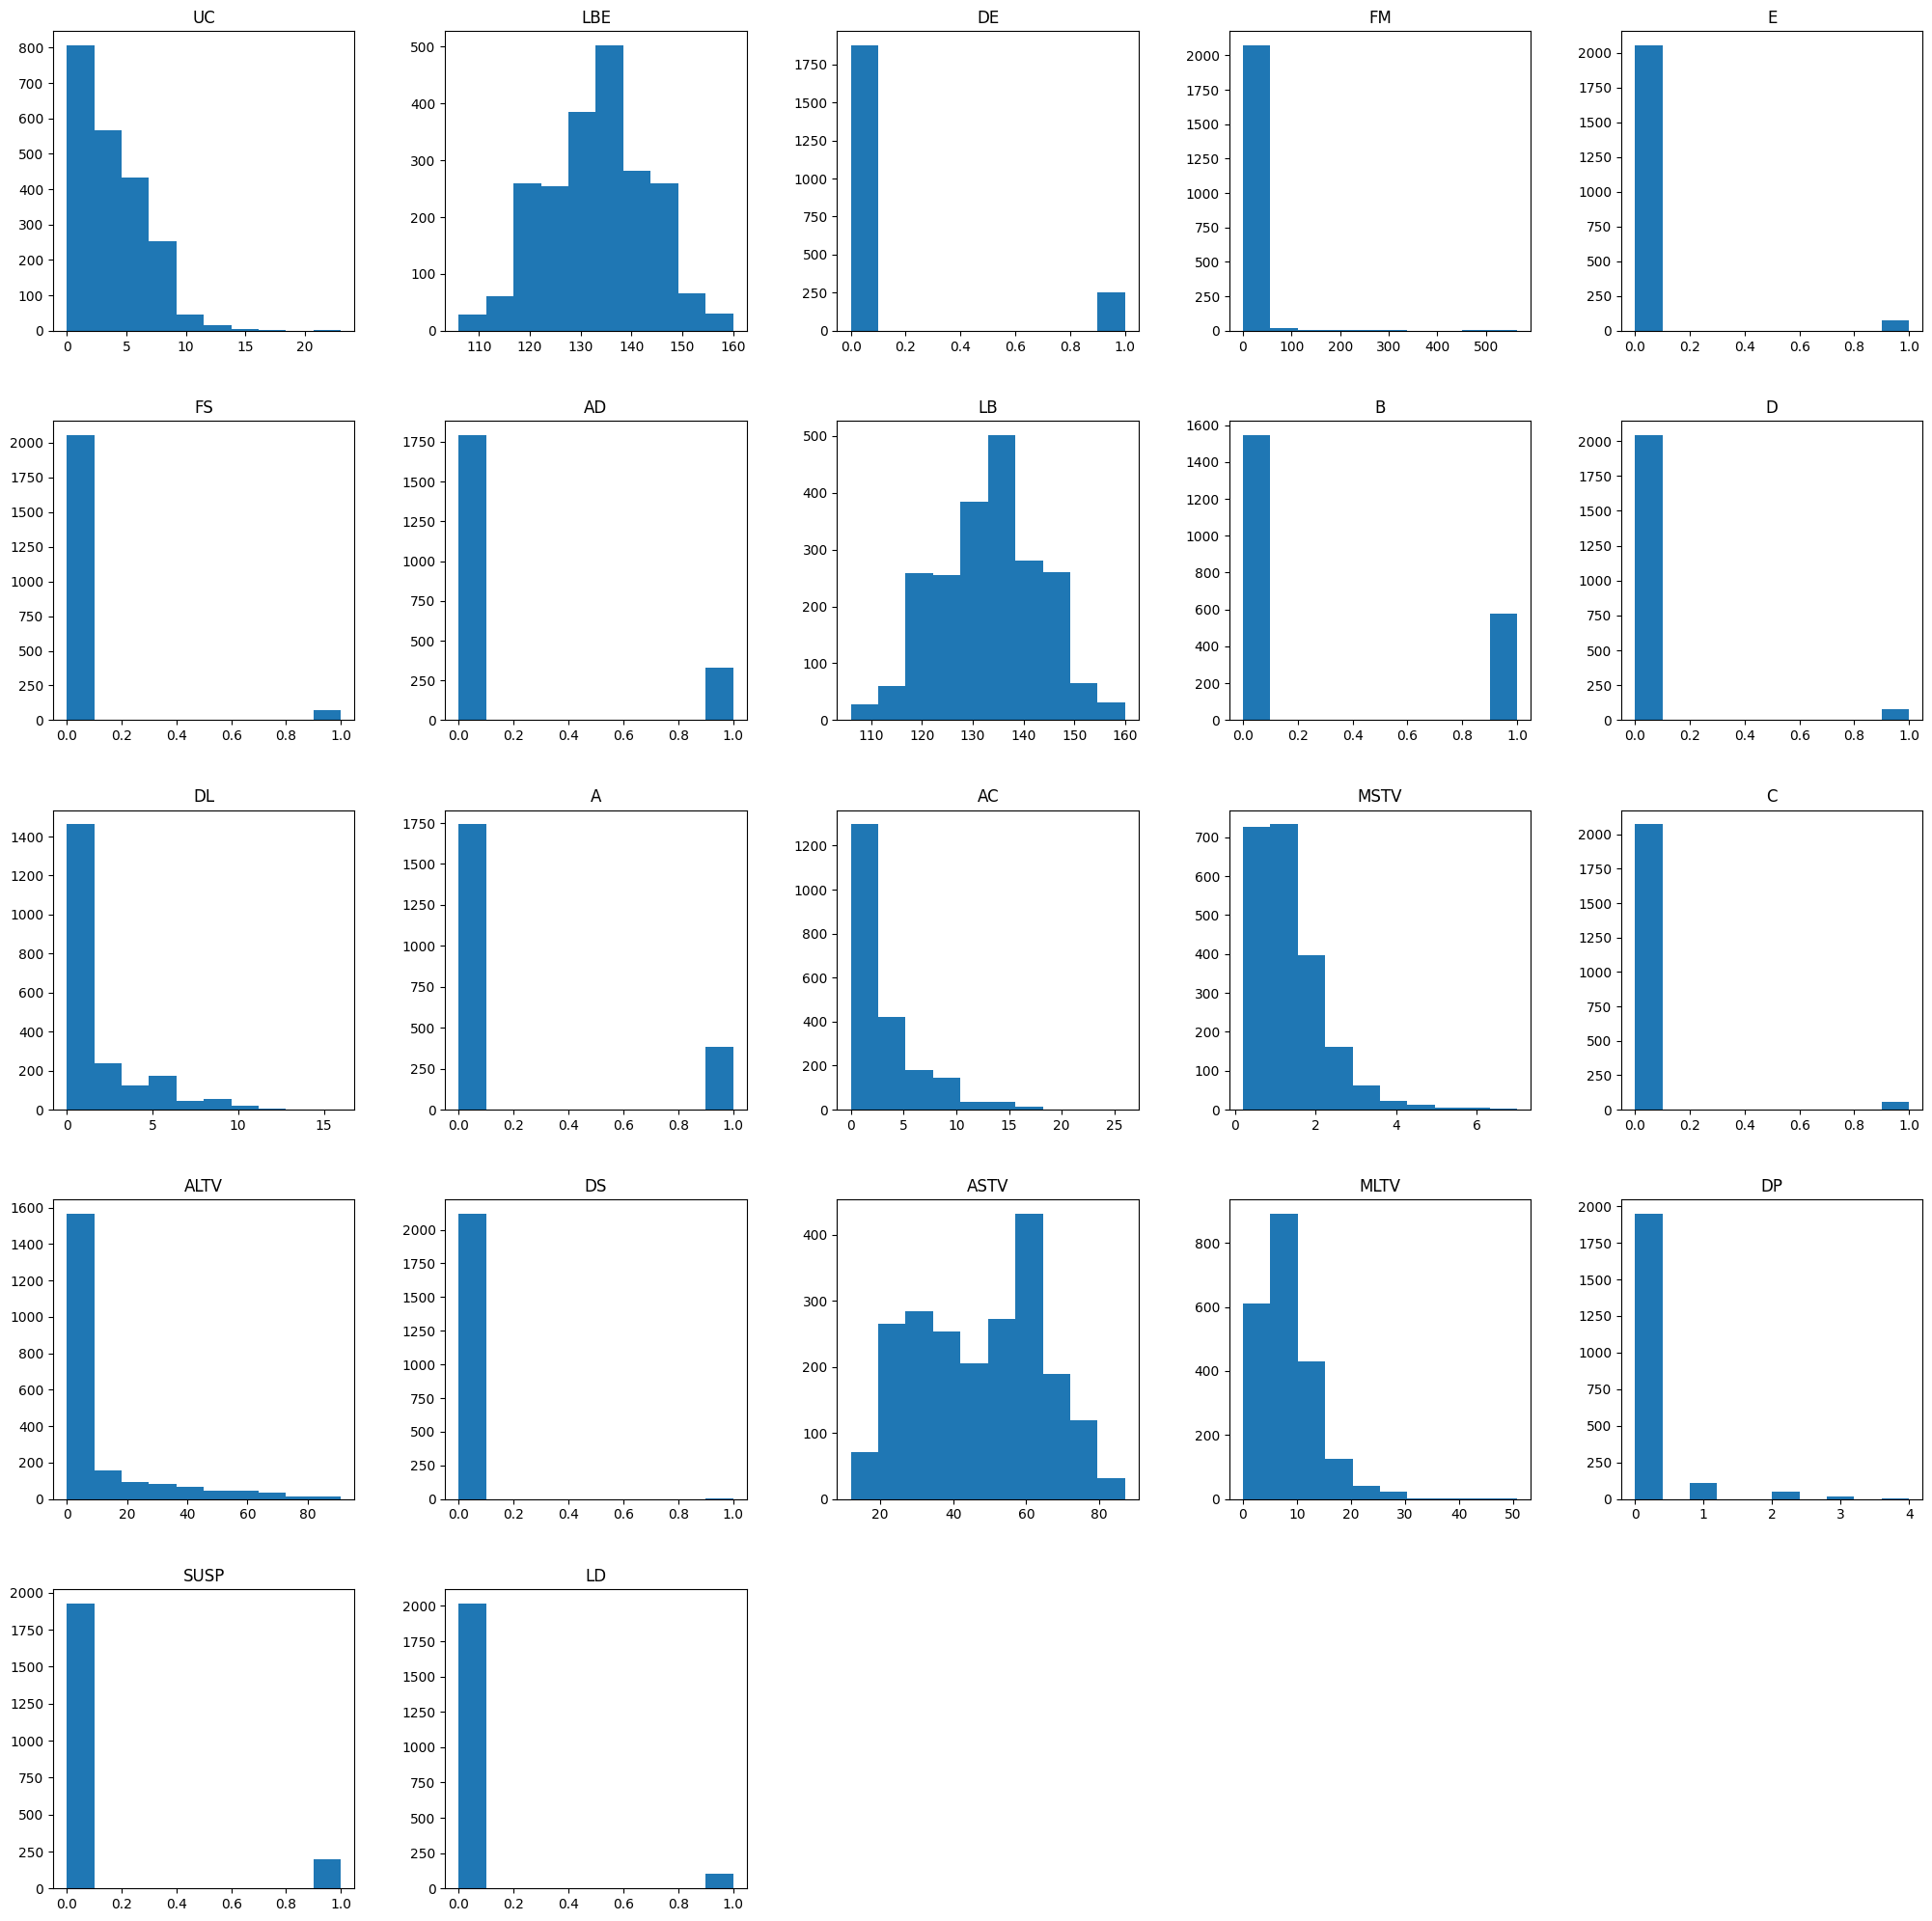

In [22]:
data[data[continuous_vars].columns.to_list()].hist(grid=False, figsize=(25, 25))
plt.show()

### <font color="cyan">Diagrama de Cajas y Bigotes</font>

<Axes: title={'center': 'Diagramas de caja y bigotes'}>

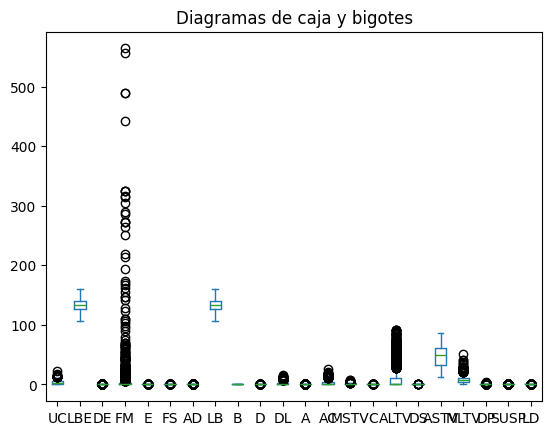

In [23]:
# Visualizar la distribución y los posibles datos atípicos
data[continuous_vars].plot(kind='box', title="Diagramas de caja y bigotes")

## <font color="cyan">Correlación entre variables</font>

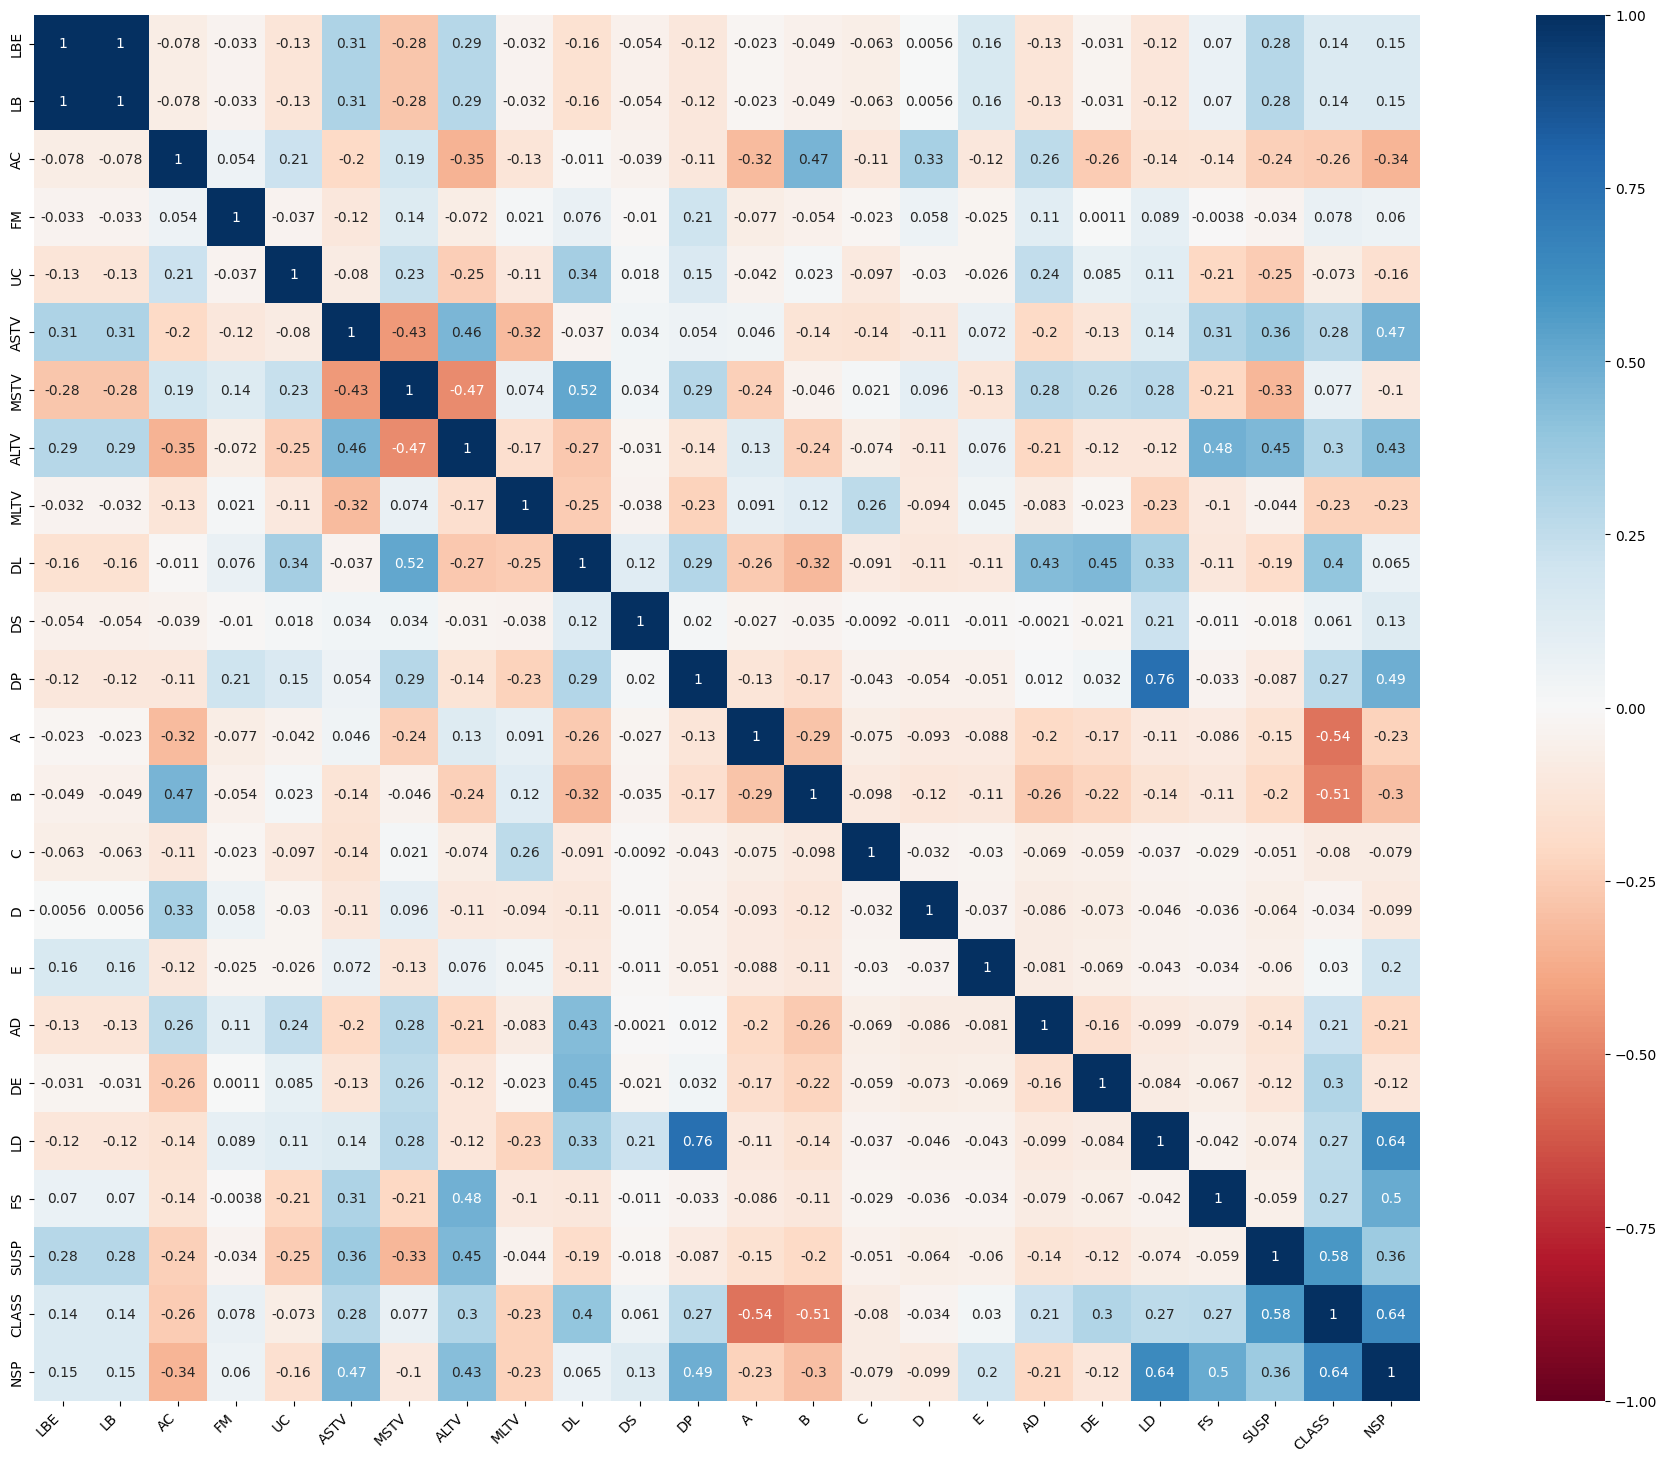

In [24]:
plt.figure(figsize=(30, 18))
corr = data.corr()
colores = sb.diverging_palette(20, 220, n=200)
ax = sb.heatmap(corr, annot=True, cmap=plt.cm.RdBu, vmin=-1, vmax=1, center=0, square=True)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right');

In [25]:
import numpy as np
# upper triangle mask to avoid duplicates and self-correlation
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
pairs = corr.where(mask).stack().sort_values(ascending=False)
# Mostrar top 10 positivas y top 10 por valor absoluto
print("Top 10 correlaciones positivas:")
print(pairs.head(10))
print("\nTop 10 correlaciones por magnitud (absoluta):")
pairs_abs = corr.where(mask).stack().abs().sort_values(ascending=False)
top_idx = pairs_abs.head(10).index
print(corr.where(mask).stack().loc[top_idx])

Top 10 correlaciones positivas:
LBE    LB       1.000000
DP     LD       0.757766
CLASS  NSP      0.643034
LD     NSP      0.635526
SUSP   CLASS    0.579770
MSTV   DL       0.516901
FS     NSP      0.501290
DP     NSP      0.490626
ALTV   FS       0.478205
ASTV   NSP      0.471191
dtype: float64

Top 10 correlaciones por magnitud (absoluta):
LBE    LB       1.000000
DP     LD       0.757766
CLASS  NSP      0.643034
LD     NSP      0.635526
SUSP   CLASS    0.579770
A      CLASS   -0.544553
MSTV   DL       0.516901
B      CLASS   -0.507403
FS     NSP      0.501290
DP     NSP      0.490626
dtype: float64


In [26]:
if 'NSP' in corr.columns:
    print(corr['NSP'].sort_values(ascending=False))
else:
    print("No se encontró 'NSP' en corr.columns")

NSP      1.000000
CLASS    0.643034
LD       0.635526
FS       0.501290
DP       0.490626
ASTV     0.471191
ALTV     0.426146
SUSP     0.364583
E        0.199349
LBE      0.148151
LB       0.148151
DS       0.131934
DL       0.065328
FM       0.060366
C       -0.079222
D       -0.098606
MSTV    -0.103382
DE      -0.122460
UC      -0.163295
AD      -0.208922
MLTV    -0.226797
A       -0.228640
B       -0.303112
AC      -0.340394
Name: NSP, dtype: float64


In [27]:
if 'CLASS' in corr.columns:
    print(corr['CLASS'].sort_values(ascending=False))
else:
    print("No se encontró 'CLASS' en corr.columns")

CLASS    1.000000
NSP      0.643034
SUSP     0.579770
DL       0.395887
ALTV     0.303050
DE       0.301747
ASTV     0.284580
FS       0.271752
DP       0.269300
LD       0.265504
AD       0.211829
LBE      0.143001
LB       0.143001
FM       0.077805
MSTV     0.077214
DS       0.060861
E        0.030323
D       -0.033533
UC      -0.073465
C       -0.079779
MLTV    -0.228310
AC      -0.255205
B       -0.507403
A       -0.544553
Name: CLASS, dtype: float64


### <font color="cyan">Conclusiones Correlación</font>

El conjunto de datos presenta dos posibles variables de salida, `CLASS` Y `NSP`, al realizar el análisis de correlación se observa lo siguiente:

* La variable de salida `NSP` presenta tres correlaciones positivas mayores a `0.5`
* La variable de salida `CLASS` presenta dos correlaciones positivas mayores a `0.5` y dos correlaciones negativas mayores a `-0.5`
* Las columnas con correlaciones menores a `0.5` seran excluidas del conjunto de datos para simplificar los entrenamientos y el análisis

In [28]:
purged_data = data[['CLASS', 'NSP', 'SUSP', 'B', 'A', 'LD', 'FS']]

purged_data.shape

(2126, 7)

## <font color="cyan">Detección de Anomalías</font>


### <font color="cyan">Método de la Desviación Estándar</font>

In [29]:
def out_std(df, column):
    global lower,upper
    # cálculo de la media y desviación estándar
    data_mean, data_std = df[column].mean(), df[column].std()
    # calculo del punto de corte
    cut_off = data_std * 3
    # Cálculo del punto por debajo y por encima del punto de corte
    lower = 0 if data_mean - cut_off < 0 else data_mean - cut_off
    upper = data_mean + cut_off
    print(f'El límite inferior es {lower:.2f}')
    print(f'El limite superior es {upper:.2f}')
    # cálculo del número de registros por debajo y por encima.
    df1 = df[df[column] > upper]
    df2 = df[df[column] < lower]
    return print('Número total de outliers', df1.shape[0]+ df2.shape[0])


In [30]:
for col in purged_data.columns.to_list():
  print(col)
  out_std(purged_data, col)
  print(25*'--')
  print(25*'--')
  

CLASS
El límite inferior es 0.00
El limite superior es 13.59
Número total de outliers 0
--------------------------------------------------
--------------------------------------------------
NSP
El límite inferior es 0.00
El limite superior es 3.15
Número total de outliers 0
--------------------------------------------------
--------------------------------------------------
SUSP
El límite inferior es 0.00
El limite superior es 0.96
Número total de outliers 197
--------------------------------------------------
--------------------------------------------------
B
El límite inferior es 0.00
El limite superior es 1.61
Número total de outliers 0
--------------------------------------------------
--------------------------------------------------
A
El límite inferior es 0.00
El limite superior es 1.34
Número total de outliers 0
--------------------------------------------------
--------------------------------------------------
LD
El límite inferior es 0.00
El limite superior es 0.71
Número

### <font color="cyan">Método Isolation Forest</font>

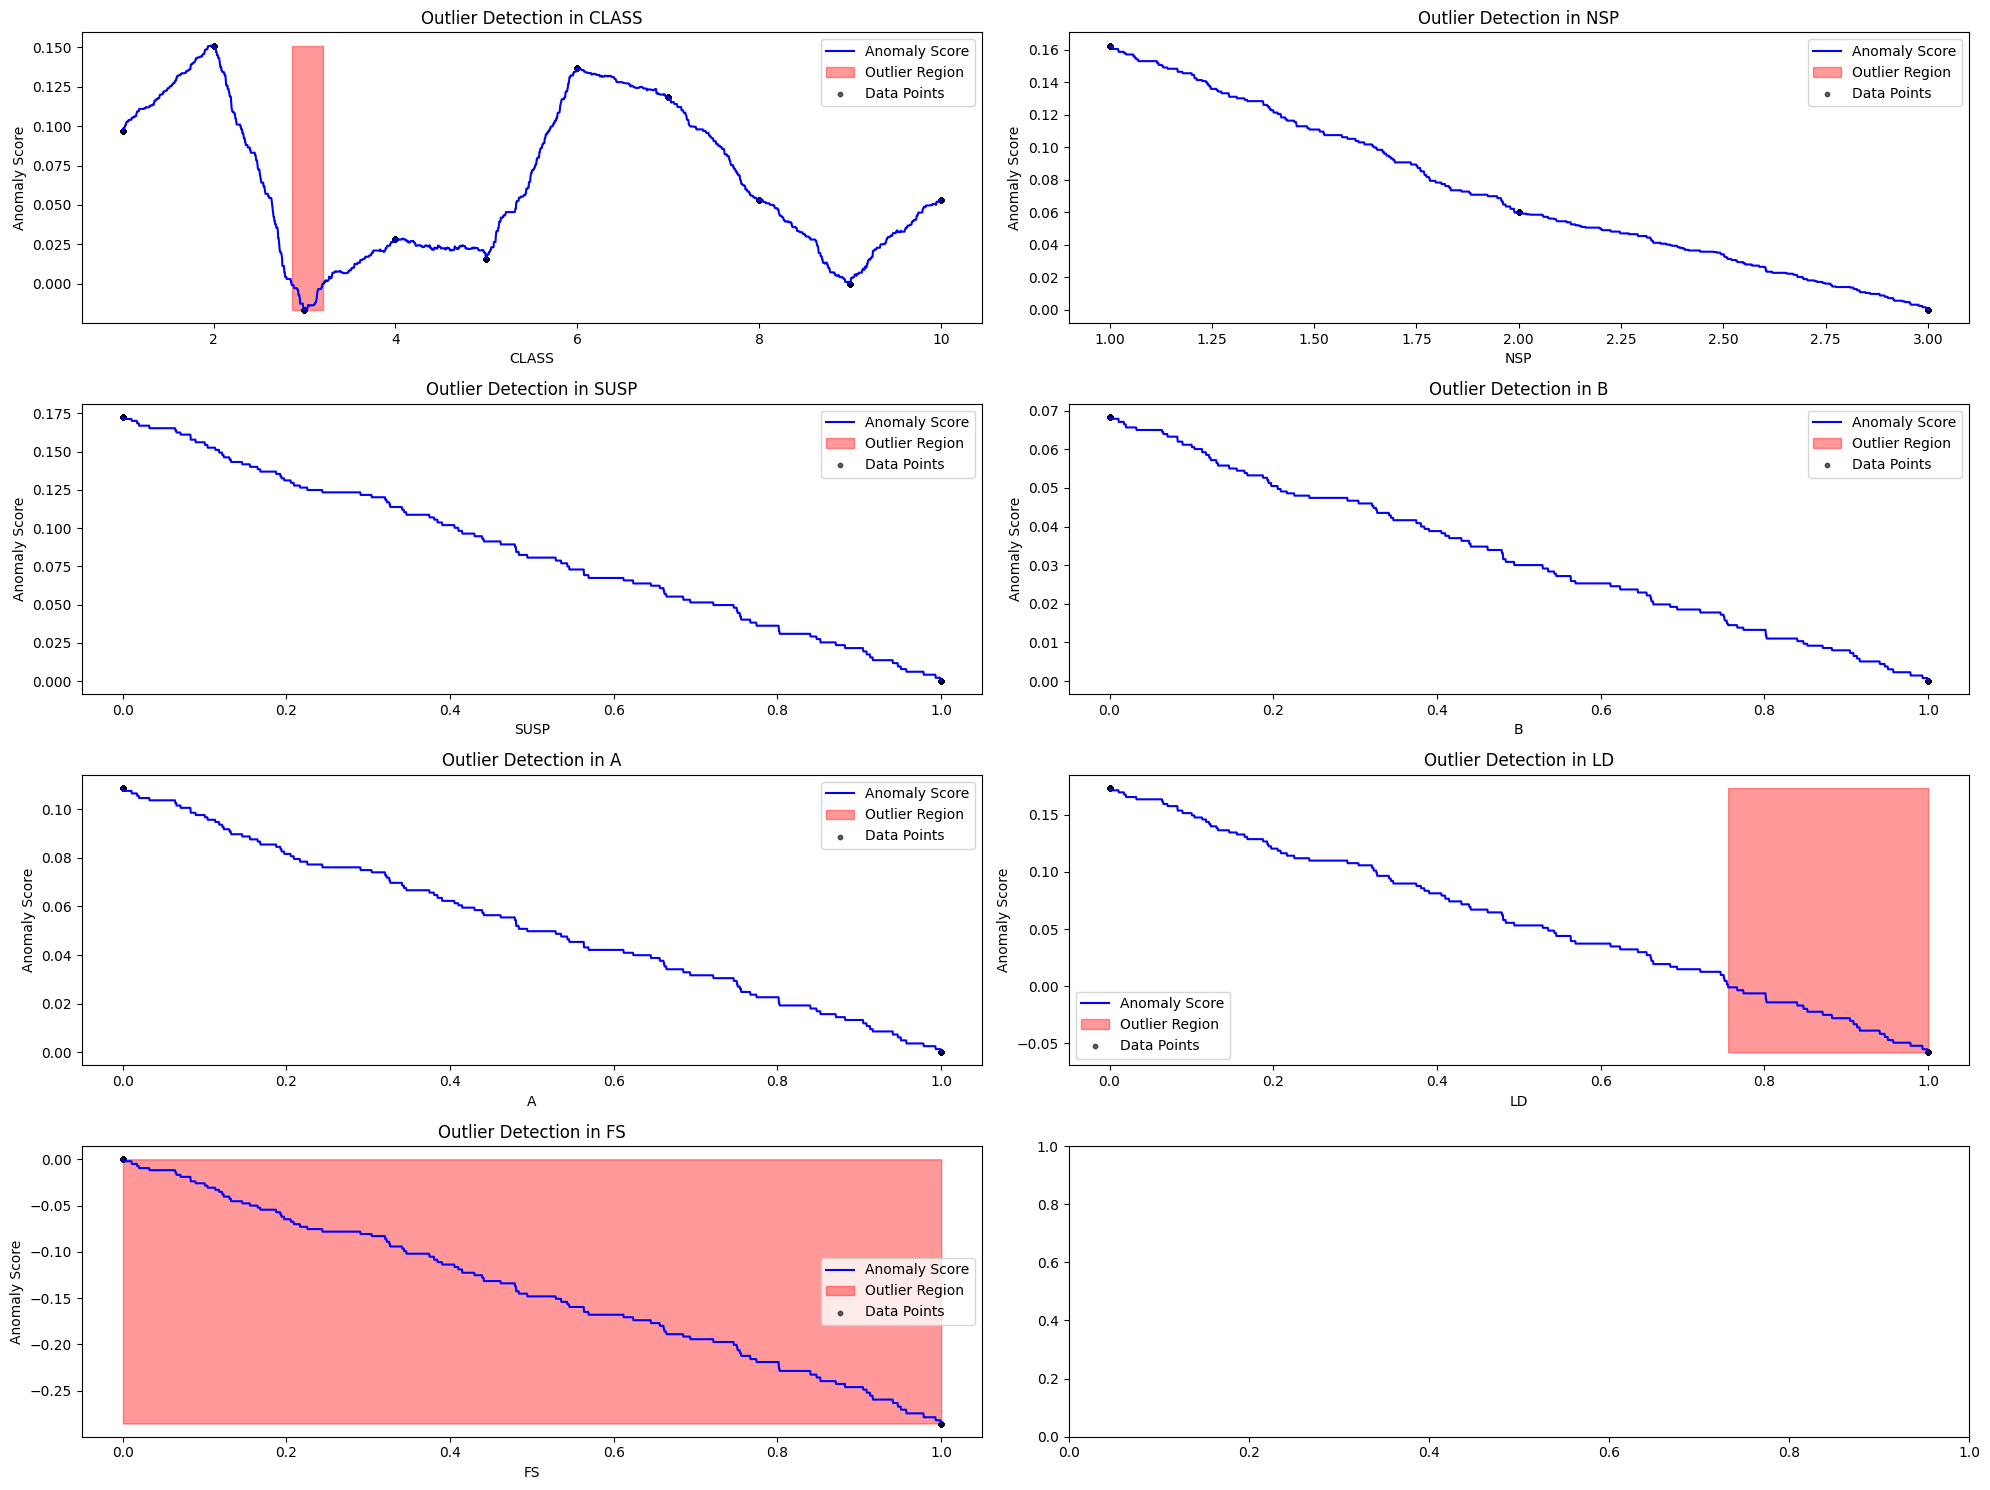

In [32]:
# lst_contvar = data.select_dtypes(include=float).columns.to_list()
lst_contvar = purged_data.columns.to_list()

fig, axs = plt.subplots(4, 2, figsize=(20, 15), facecolor='w', edgecolor='k')
# fig, axs = plt.subplots(1, len(lst_contvar), figsize=(50, 25), facecolor='w', edgecolor='k')
axs = axs.ravel()

for i, column in enumerate(lst_contvar):
    # isolation_forest = IsolationForest(contamination='auto', random_state=42)
    isolation_forest = IsolationForest(contamination=0.05, random_state=42)
    isolation_forest.fit(purged_data[column].values.reshape(-1, 1))

    # Se genera un conjunto de valores en el mismo rango que la variable
    xx = np.linspace(purged_data[column].min(), purged_data[column].max(), len(purged_data[lst_contvar])).reshape(-1,1)

    # Calculamos la puntuación de anomalía
    anomaly_score = isolation_forest.decision_function(xx)
    outlier = isolation_forest.predict(xx)

    # Graficamos los resultados
    axs[i].plot(xx, anomaly_score, label='Anomaly Score', color='blue')
    axs[i].fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score),
                        where=outlier == -1, color='red', alpha=0.4, label='Outlier Region')

    # Añadir scatter plot con los datos reales y su puntuación de anomalía
    data_anomaly_score = isolation_forest.decision_function(purged_data[column].values.reshape(-1, 1))
    axs[i].scatter(purged_data[column], data_anomaly_score, color='black', s=10, alpha=0.6, label='Data Points')


    axs[i].legend()
    axs[i].set_title(f"Outlier Detection in {column}")
    axs[i].set_xlabel(column)
    axs[i].set_ylabel("Anomaly Score")

plt.tight_layout()
plt.show()

### <font color="cyan">Detección de Anomalía por Instancia</font>

#### Variable NSP

In [33]:
nsp_x = purged_data.drop(columns=['NSP']).to_numpy()
nsp_y = purged_data['NSP'].to_numpy()


In [34]:
print(f'data.shape: {purged_data.shape} - nsp_x.shape: {nsp_x.shape} - nsp_y.shape: {nsp_y.shape}')

data.shape: (2126, 7) - nsp_x.shape: (2126, 6) - nsp_y.shape: (2126,)


In [35]:
nsp_x_train, nsp_x_test, nsp_y_train, nsp_y_test = train_test_split(nsp_x, nsp_y, test_size=0.2, stratify=nsp_y, random_state=42)


#### Normalizacion

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
nsp_x_train = scaler.fit_transform(nsp_x_train)
nsp_x_test = scaler.transform(nsp_x_test)

In [37]:
nsp_ift = IsolationForest(random_state=42, contamination="auto")
nsp_ift.fit(nsp_x_train)

nsp_ift_pred = nsp_ift.predict(nsp_x_train)

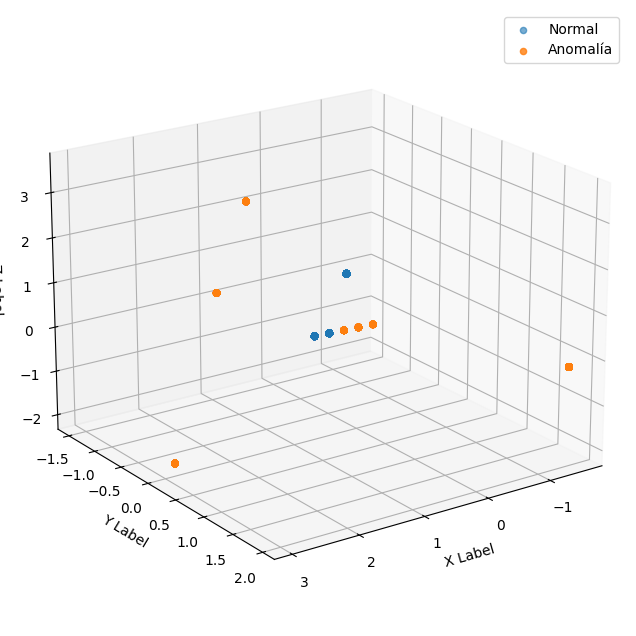

In [38]:
from sklearn.decomposition import PCA

nsp_pca_3d = PCA(n_components=3, random_state=42)
nsp_X3d_pca = nsp_pca_3d.fit_transform(nsp_x_train)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d') # or fig.add_subplot(111, projection='3d')

# -------------------------
# Gráfica
# -------------------------
#ax.figure(figsize=(7, 5))
ax.scatter(
    nsp_X3d_pca[nsp_ift_pred == 1, 0],
    nsp_X3d_pca[nsp_ift_pred == 1, 1],
    nsp_X3d_pca[nsp_ift_pred == 1, 2],
    alpha=0.6,
    label='Normal'
)
ax.scatter(
    nsp_X3d_pca[nsp_ift_pred == -1, 0],
    nsp_X3d_pca[nsp_ift_pred == -1, 1],
    nsp_X3d_pca[nsp_ift_pred == -1, 2],
    alpha=0.8,
    label='Anomalía'
)

ax.view_init(elev=20, azim=55)

# 4. Set labels for the axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

ax.legend()
# 5. Display the plot
plt.show()

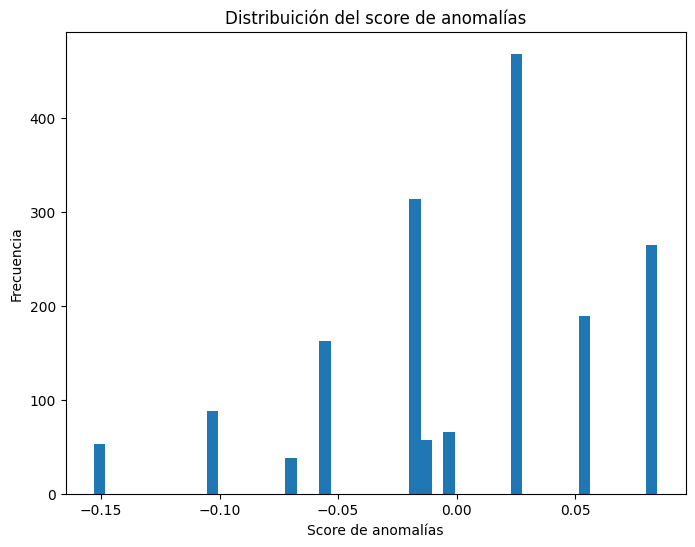

In [39]:
nsp_ift_scores = nsp_ift.decision_function(nsp_x_train)

plt.figure(figsize=(8, 6))
plt.hist(nsp_ift_scores, bins=50)
plt.title("Distribuición del score de anomalías")
plt.xlabel("Score de anomalías")
plt.ylabel("Frecuencia")
plt.show()

#### <font color="cyan">Agrupamiento</font>

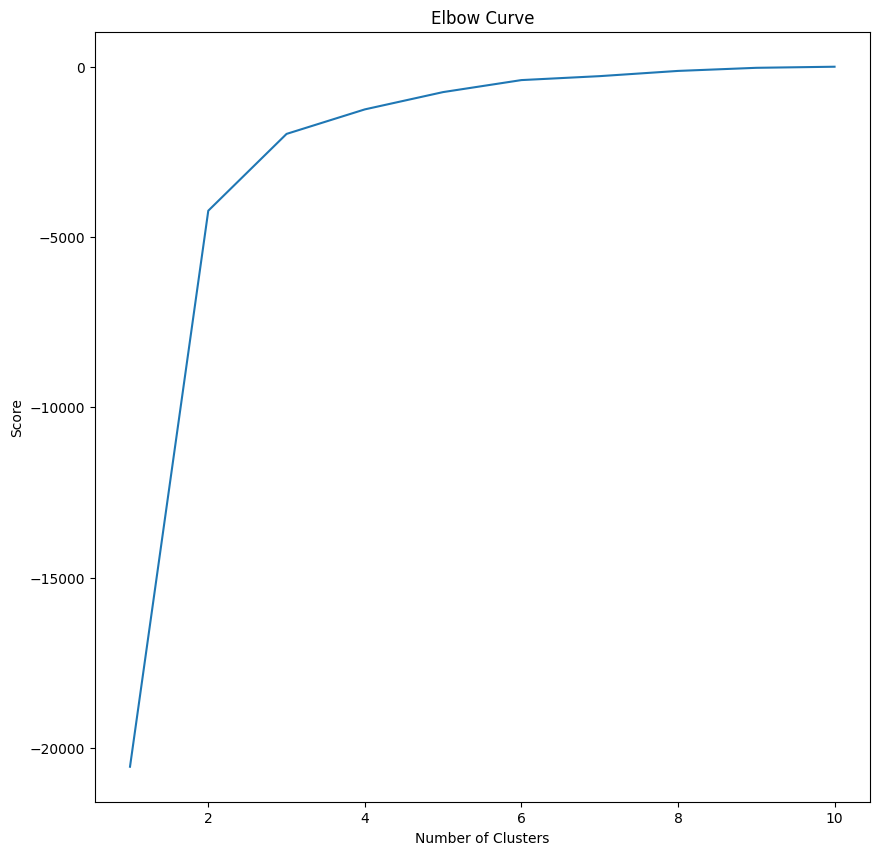

In [87]:
from sklearn.cluster import KMeans

nsp_range = range(1, 11)
kmeans = [KMeans(n_clusters=i) for i in nsp_range]
kmeans
nsp_kmeans_score = [kmeans[i].fit(nsp_x).score(nsp_x) for i in range(len(kmeans))]
nsp_kmeans_score
plt.rcParams['figure.figsize'] = (10, 10)
plt.plot(nsp_range, nsp_kmeans_score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

In [90]:
nsp_cluster = 2
opt_nsp = kmeans[nsp_cluster].fit(nsp_x_train)
opt_nsp

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


#### Variable CLASS

In [41]:
class_x = purged_data.drop(columns=['CLASS']).to_numpy()
class_y = purged_data['CLASS'].to_numpy()


In [42]:
print(f'data.shape: {purged_data.shape} - nsp_x.shape: {class_x.shape} - nsp_y.shape: {class_y.shape}')


data.shape: (2126, 7) - nsp_x.shape: (2126, 6) - nsp_y.shape: (2126,)


In [43]:
class_x_train, class_x_test, class_y_train, class_y_test = train_test_split(class_x, class_y, test_size=0.2, stratify=class_y, random_state=42)

In [44]:
from sklearn.preprocessing import StandardScaler

class_scaler = StandardScaler()
class_x_train = class_scaler.fit_transform(class_x_train)
class_x_test = class_scaler.transform(class_x_test)

In [45]:
class_ift = IsolationForest(random_state=42, contamination="auto")
class_ift.fit(class_x_train)

class_ift_pred = class_ift.predict(class_x_train)

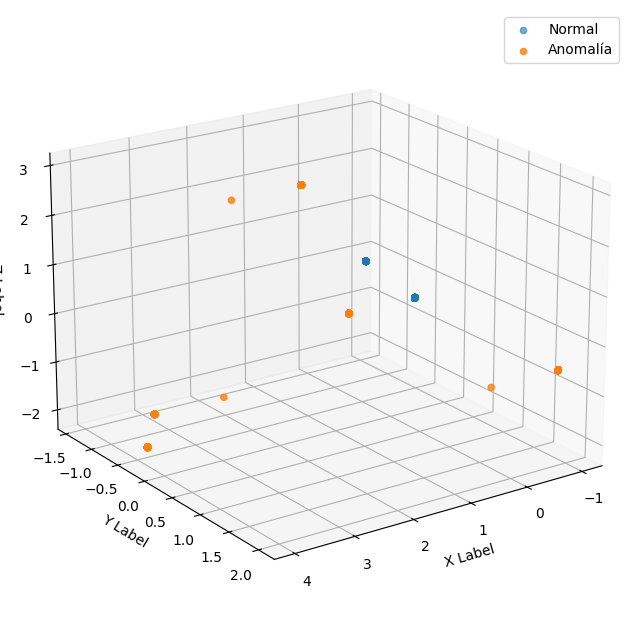

In [46]:
from sklearn.decomposition import PCA

class_pca_3d = PCA(n_components=3, random_state=42)
class_X3d_pca = class_pca_3d.fit_transform(class_x_train)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(projection='3d') # or fig.add_subplot(111, projection='3d')

# -------------------------
# Gráfica
# -------------------------
#ax.figure(figsize=(7, 5))
ax.scatter(
    class_X3d_pca[class_ift_pred == 1, 0],
    class_X3d_pca[class_ift_pred == 1, 1],
    class_X3d_pca[class_ift_pred == 1, 2],
    alpha=0.6,
    label='Normal'
)
ax.scatter(
    class_X3d_pca[class_ift_pred == -1, 0],
    class_X3d_pca[class_ift_pred == -1, 1],
    class_X3d_pca[class_ift_pred == -1, 2],
    alpha=0.8,
    label='Anomalía'
)

ax.view_init(elev=20, azim=55)

# 4. Set labels for the axes
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

ax.legend()

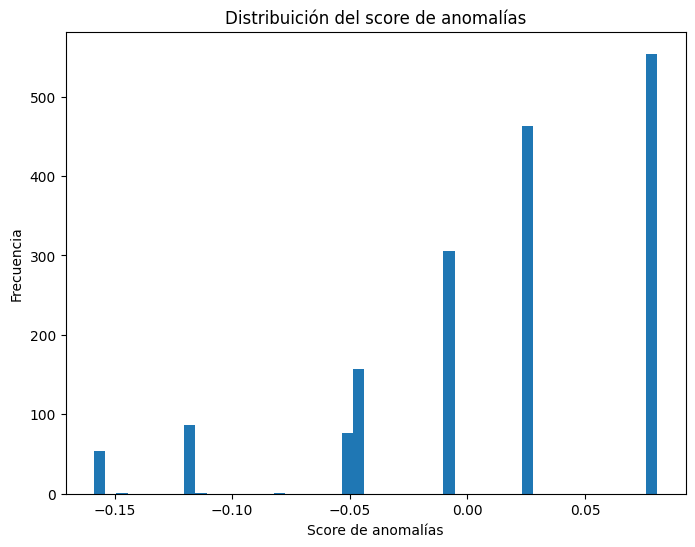

In [47]:
class_ift_scores = class_ift.decision_function(class_x_train)

plt.figure(figsize=(8, 6))
plt.hist(class_ift_scores, bins=50)
plt.title("Distribuición del score de anomalías")
plt.xlabel("Score de anomalías")
plt.ylabel("Frecuencia")
plt.show()

#### <font color="cyan">Agrupamiento</font>

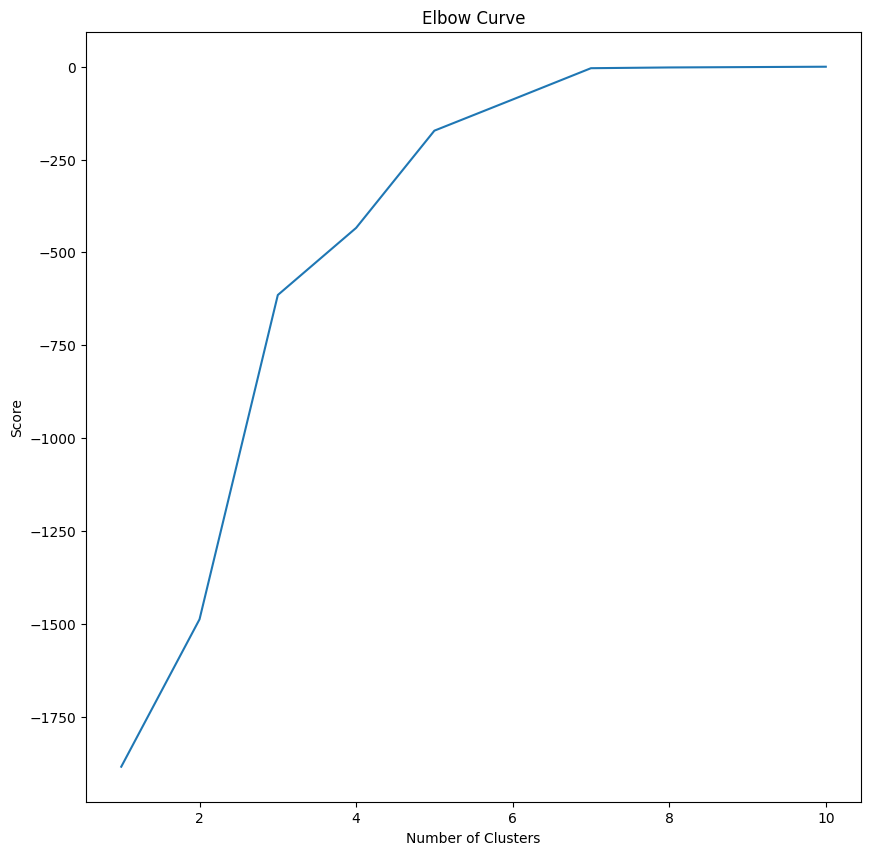

In [48]:
class_range = range(1, 11)
kmeans_class = [KMeans(n_clusters=i) for i in class_range]
kmeans_class
class_kmeans_score = [kmeans_class[i].fit(class_x).score(class_x) for i in range(len(kmeans_class))]
class_kmeans_score
plt.rcParams['figure.figsize'] = (10, 10)
plt.plot(class_range, class_kmeans_score)
plt.xlabel('Number of Clusters')
plt.ylabel('Score')
plt.title('Elbow Curve')
plt.show()

In [79]:
class_cluster = 4
opt_kmeans = kmeans_class[class_cluster].fit(class_x_train)
opt_kmeans

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'
